In [297]:
import numpy as np
import matplotlib.pyplot as plt

# 14.1

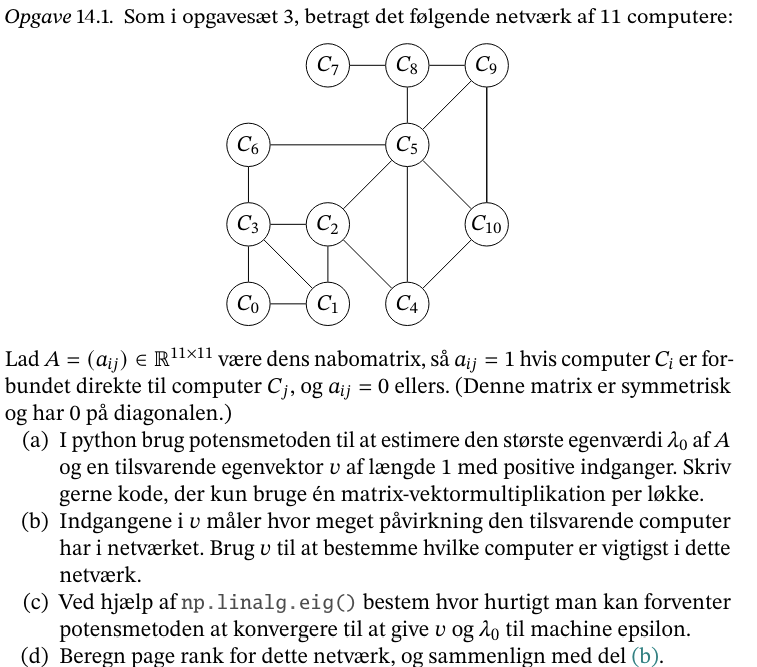

## (a)

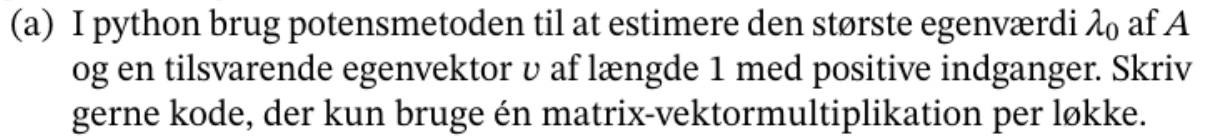

In [298]:
A = np.array([[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0.],
              [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0.],
              [0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0.],
              [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0.],
              [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1.],
              [0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1.],
              [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0.],
              [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0.],
              [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0.],
              [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1.],
              [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0.]])

In [299]:
# Original potensmetode
def potens_skridt(a, w):
    v = a @ w
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [300]:
# Ændret potensmetode
def potens_skridt(a, w):
    v = a @ w
    lambda_ny = np.vdot(w, v)
    v /= np.linalg.norm(v)
    return lambda_ny, v

In [301]:
rng = np.random.default_rng()


rows, cols = A.shape
w = rng.standard_normal((rows, 1))

[-10.92131823  -0.90595393   0.1996664    1.44550121   2.40440548
   2.97990961   3.28048894   3.42703791   3.49624684   3.5284679
   3.54337489   3.55025281   3.5534225    3.55488255   3.55555495
   3.55586458   3.55600717   3.55607283   3.55610306   3.55611698
   3.55612339   3.55612634   3.5561277    3.55612833   3.55612862
   3.55612875   3.55612881   3.55612884   3.55612885   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.55612886   3.55612886   3.55612886   3.55612886   3.55612886
   3.556128

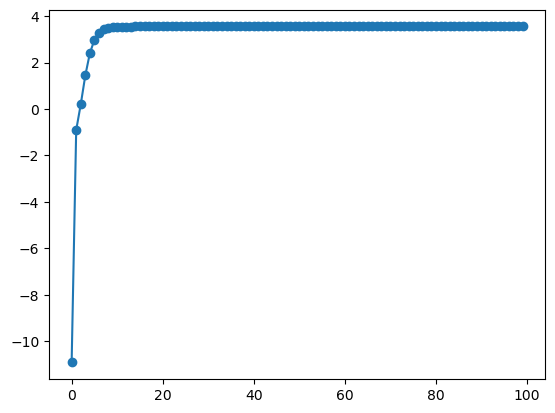

In [302]:
n = 100
lambda_out = np.zeros(n)
for k in range(n):
    lambda_out[k], w = potens_skridt(A, w)
print(lambda_out)

plt.plot(lambda_out, '-o')


In [303]:
lambda0 = lambda_out[-1]
v = w

lambda0, v

(3.5561288647251303,
 array([[0.13910858],
        [0.22296999],
        [0.38208338],
        [0.27171805],
        [0.34594279],
        [0.5181069 ],
        [0.22210245],
        [0.07106917],
        [0.25273111],
        [0.30956833],
        [0.33002685]]))

## (b)

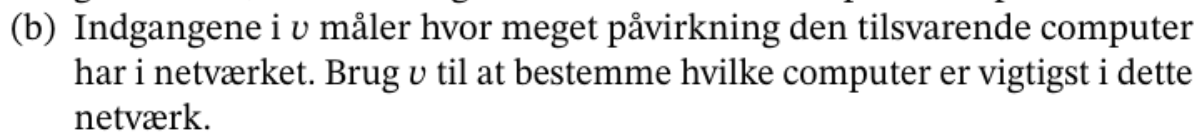

In [304]:
# Finder den største indgang i v
np.argmax(v)

5

Computer 5 må være vigtigst i dette netværk. Dette giver også lidt intuitiv mening da den er helt central i netværket.

## (c)

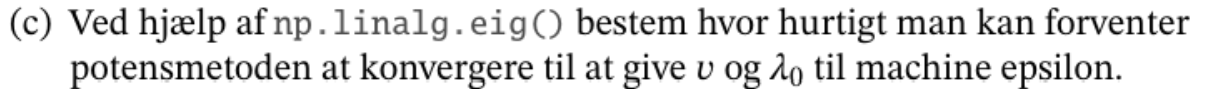

Her bruger jeg:

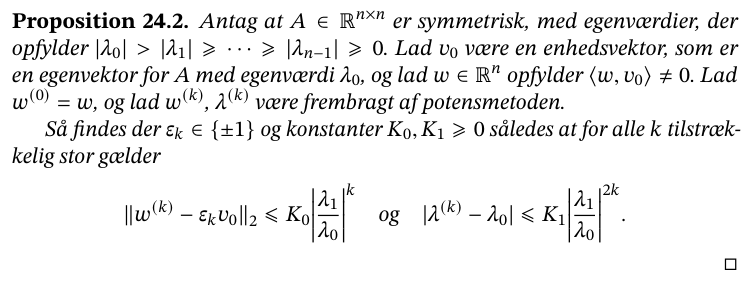

Vi vil gerne vide hvor mange iterationer $k$ der skal til før at $||w^{(k) - \epsilon_k v_0}||_2 \leq \epsilon_{machine}$ og $|\lambda^{(k) - \lambda_0}| \leq \epsilon_{machine}$

Vi sætter altså højresiden af udsagnene lig machine epsilon, og løser for k.

In [305]:
eigvals, eigvecs = np.linalg.eig(A)

eigvals, np.round(eigvecs, 3)

(array([ 3.55612886,  2.45619326, -2.41297504,  1.16230549,  0.52432951,
         0.36969609, -0.30740674, -0.8323107 , -1.201142  , -1.57972663,
        -1.7350921 ]),
 array([[-0.139, -0.39 , -0.209,  0.211,  0.175,  0.407,  0.35 , -0.558,
          0.092, -0.317,  0.006],
        [-0.223, -0.464,  0.117,  0.106,  0.306,  0.106, -0.178,  0.159,
         -0.656,  0.297, -0.172],
        [-0.382, -0.255, -0.461, -0.227,  0.2  , -0.413, -0.366,  0.12 ,
          0.151, -0.356,  0.131],
        [-0.272, -0.495,  0.388,  0.139, -0.214,  0.045,  0.07 ,  0.306,
          0.546,  0.204,  0.161],
        [-0.346,  0.098,  0.071, -0.453,  0.215, -0.228,  0.343, -0.238,
          0.185,  0.35 , -0.481],
        [-0.518,  0.234,  0.536, -0.056, -0.202, -0.076, -0.123, -0.327,
         -0.255, -0.289,  0.264],
        [-0.222, -0.106, -0.383,  0.072, -0.793, -0.083,  0.172,  0.025,
         -0.242,  0.054, -0.245],
        [-0.071,  0.108,  0.109,  0.483,  0.213, -0.437,  0.509,  0.322,
         

## (d)

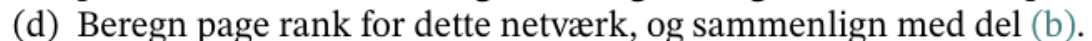

Først opstiller jeg en matrix under følgende betingelse.

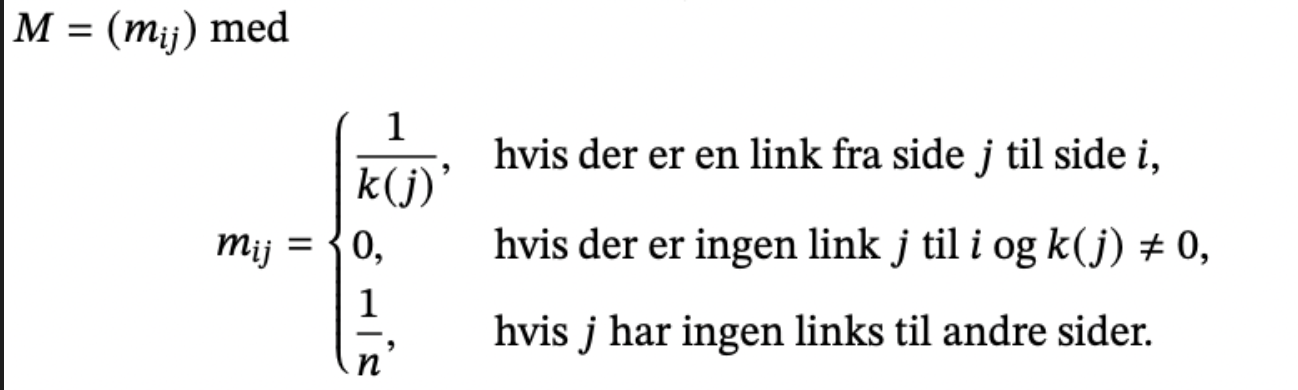

Dette kan gøres ved blot at gå igennem hver søjle, og udføre følgende:

In [306]:
m, _ = A.shape
sumvec = np.ones((1, m))
M = np.ndarray((m, m))

for i in range(m):
    nol = sumvec @ A[:, i]
    M[:, i] = A[:, i] * 1/nol
print(np.array_str(M, precision=3))

[[0.    0.333 0.    0.25  0.    0.    0.    0.    0.    0.    0.   ]
 [0.5   0.    0.25  0.25  0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.333 0.    0.25  0.333 0.167 0.    0.    0.    0.    0.   ]
 [0.5   0.333 0.25  0.    0.    0.    0.5   0.    0.    0.    0.   ]
 [0.    0.    0.25  0.    0.    0.167 0.    0.    0.    0.    0.333]
 [0.    0.    0.25  0.    0.333 0.    0.5   0.    0.333 0.333 0.333]
 [0.    0.    0.    0.25  0.    0.167 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.333 0.    0.   ]
 [0.    0.    0.    0.    0.    0.167 0.    1.    0.    0.333 0.   ]
 [0.    0.    0.    0.    0.    0.167 0.    0.    0.333 0.    0.333]
 [0.    0.    0.    0.    0.333 0.167 0.    0.    0.    0.333 0.   ]]


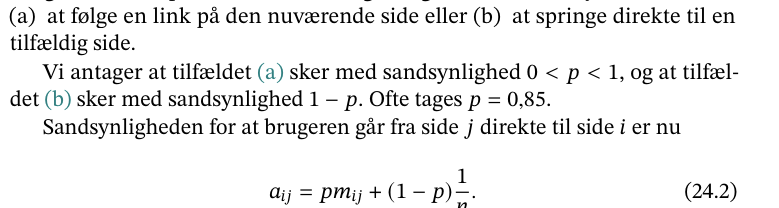

In [307]:
# Jeg laver nu en ny matrix B, som indeholder sandsynligheden for at man tilgår et andet element fra netværket, fra et hvert andet.

p = 0.85
n, _ = M.shape
B = p * M + ((1-p)/n) * np.ones_like(M)

print(np.array_str(B, precision=3))

[[0.014 0.297 0.014 0.226 0.014 0.014 0.014 0.014 0.014 0.014 0.014]
 [0.439 0.014 0.226 0.226 0.014 0.014 0.014 0.014 0.014 0.014 0.014]
 [0.014 0.297 0.014 0.226 0.297 0.155 0.014 0.014 0.014 0.014 0.014]
 [0.439 0.297 0.226 0.014 0.014 0.014 0.439 0.014 0.014 0.014 0.014]
 [0.014 0.014 0.226 0.014 0.014 0.155 0.014 0.014 0.014 0.014 0.297]
 [0.014 0.014 0.226 0.014 0.297 0.014 0.439 0.014 0.297 0.297 0.297]
 [0.014 0.014 0.014 0.226 0.014 0.155 0.014 0.014 0.014 0.014 0.014]
 [0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.297 0.014 0.014]
 [0.014 0.014 0.014 0.014 0.014 0.155 0.014 0.864 0.014 0.297 0.014]
 [0.014 0.014 0.014 0.014 0.014 0.155 0.014 0.014 0.297 0.014 0.297]
 [0.014 0.014 0.014 0.014 0.297 0.155 0.014 0.014 0.014 0.297 0.014]]


In [308]:
# Bestemmelse af egenvektor for B

rng = np.random.default_rng()
v = rng.random((n, 1))
v /= np.linalg.norm(v)
nøjagtighed = 1e-9

while True:
    v_ny = B @ v
    v_ny /= np.linalg.norm(v_ny)
    if np.vdot(v_ny, v) > 1.0 - nøjagtighed:
        rang_v = v_ny
        break
    else:
        v = v_ny

print('rang_v:')
print(rang_v)
print('lambda =', np.vdot(rang_v, B @ rang_v))
print('webside med største page rank:', rang_v.argmax())

rang_v:
[[0.19813563]
 [0.27738814]
 [0.3465018 ]
 [0.36108773]
 [0.26598134]
 [0.51536619]
 [0.19254683]
 [0.12907076]
 [0.30444566]
 [0.2786093 ]
 [0.27010741]]
lambda = 0.9999991169302932
webside med største page rank: 5


Som ses ovenfor, så stemmer b) overens med opgave d)

# 14.2

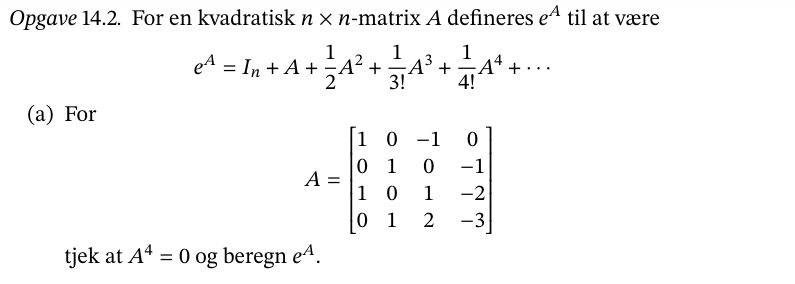
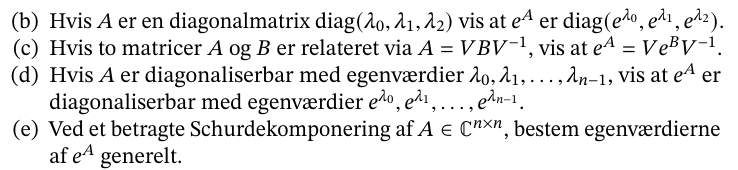

## (a)

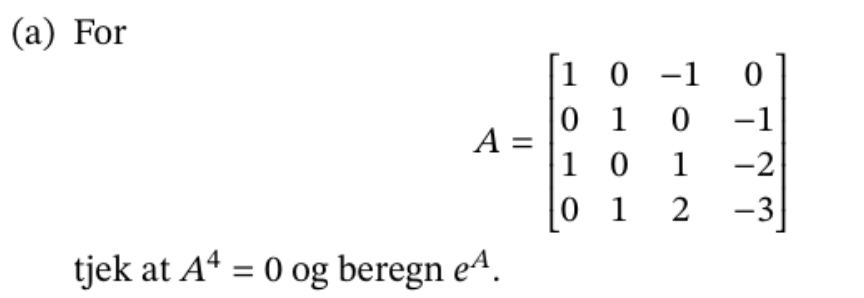

In [309]:
A = np.array([[1, 0, -1, 0],
              [0, 1, 0, -1],
              [1, 0, 1, -2],
              [0, 1, 2, -3]], dtype=float)

A, A@A@A@A

(array([[ 1.,  0., -1.,  0.],
        [ 0.,  1.,  0., -1.],
        [ 1.,  0.,  1., -2.],
        [ 0.,  1.,  2., -3.]]),
 array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]))

Vi ved at $A^k = 0$ for alle $k > 3$.

In [310]:
eA = np.eye(4) + A + 1/2 * A @ A + 1/6 * A @ A @ A

eA

array([[ 1.66666667,  0.33333333, -1.66666667,  0.66666667],
       [-0.33333333,  2.33333333, -0.66666667, -0.33333333],
       [ 1.66666667, -0.66666667,  0.33333333, -0.33333333],
       [ 0.66666667,  0.33333333,  0.33333333, -0.33333333]])

## (b)

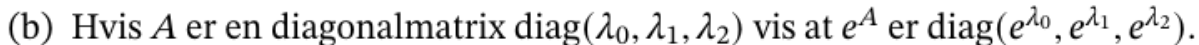

Vi ved at $e^x$ er defineret ved den uendelige sum: $e^x = \sum_{k=0}^{\infty} \frac{x^k}{k!}$

Vi kan nu opskrive $e^A$:

$$e^A = \sum_{k=0}^{\infty} \frac{A^k}{k!} = I_n + A + \frac{A^2}{2} + \frac{A^3}{6} + \dots$$

Vi ved at en diagonal matrix opløftet i en kvotient $k$, blot vil have sine diagonalindgange opløftet i kvotienten $k$.

Dermed må hver diagonal indgang i $e^A$, blot være summen for den "normale" exponentialfunktion. Derudover er $e^A$ blot en sum af diagonalmatricer, og dermed må den selv være en diagonal matrix.

## (c)

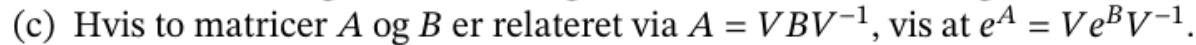

Vi kan omskrive følgende:

$$Ve^BV^{-1} = VI_nV^{-1} + VBV^{-1} + V \frac{B^2}{2} V^{-1} + V \frac{B^3}{6} V^{-1} + \dots$$
$$e^A = I_n + A + \frac{A^2}{2} + \frac{A^3}{6} + \dots$$

Desuden har vi at:

$$e^A - V B V^{-1} = 0$$

Hvis vi nu kigger ovenfor, så kan vi se at $VI_nV^{-1}$ og $I_n$ går ud med hinanden. Det samme gør $VBV^-1$ og $A$. 

Fra en tidligere opgave fik vi følgende resultat, og dermed ved vi også at resten går ud med hinanden:

Hvis $A = VBV^{-1}$, så er $A^k = VB^k V^{-1}$


## (d)

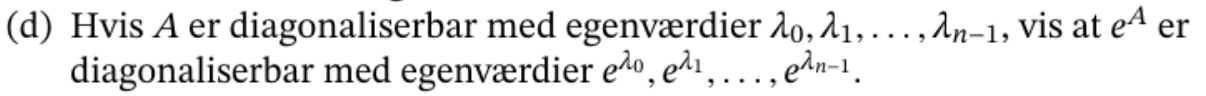

På baggrund af opg (c) ved vi at $e^A = V e^\Lambda V^{-1}$, og fra opg (b) ved vi at hvis $\Lambda$ er en diagonal matrix, så er $e^\Lambda$ også en diagonal matrix med eksponentialer på diagonal indgangene. Dermed må det være vist.

## (e)

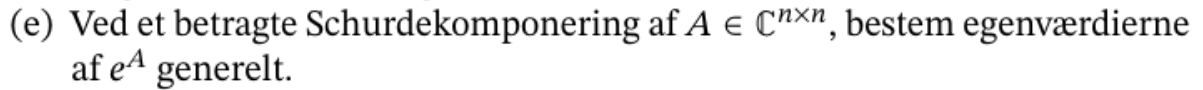

In [311]:
A

array([[ 1.,  0., -1.,  0.],
       [ 0.,  1.,  0., -1.],
       [ 1.,  0.,  1., -2.],
       [ 0.,  1.,  2., -3.]])

$\color{red} \text{Kig på denne delopgave igen}$

# 14.3

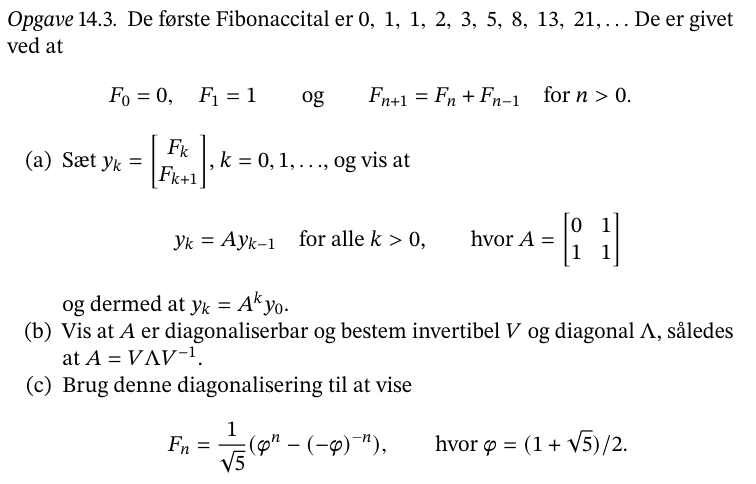

## (a)
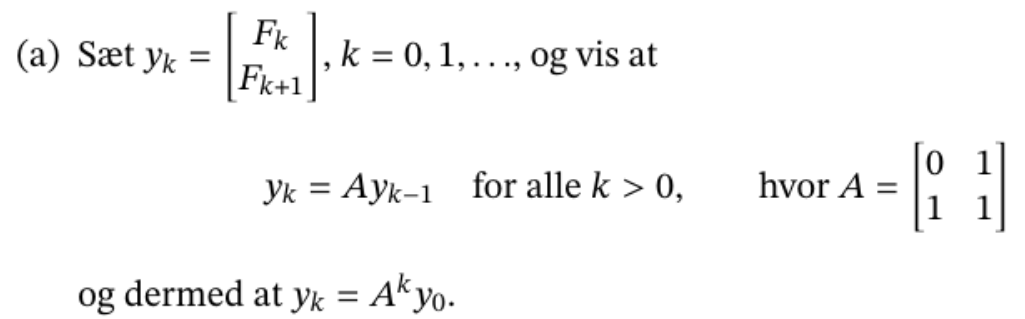

$$y_k = Ay_{k-1}$$

$$\Updownarrow$$

$$\begin{bmatrix} F_k \\ F_{k+1} \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 1 & 1 \end{bmatrix} \begin{bmatrix} F_{k-1} \\ F_{k} \end{bmatrix}$$

$$\Updownarrow$$

$$\begin{bmatrix} F_k \\ F_{k+1} \end{bmatrix} = \begin{bmatrix} F_{k} \\ F_{k-1} + F_{k} \end{bmatrix}$$

Per definitionen af fibonaccitallene, så må dette være sandt.

## (b)

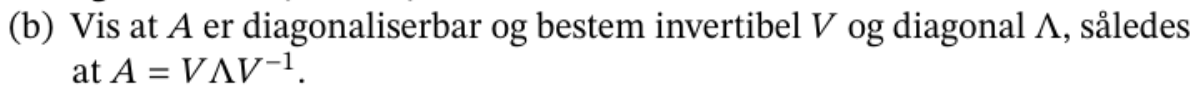

Hvis A har 2 lineært uafhængige egenvektorer, så er den diagonaliserbar:

In [312]:
A = np.array([[0, 1],
              [1, 1]], dtype = "float")

A

array([[0., 1.],
       [1., 1.]])

In [313]:
eigvals, eigvecs = np.linalg.eig(A)

eigvecs

array([[-0.85065081, -0.52573111],
       [ 0.52573111, -0.85065081]])

In [314]:
V = np.hstack((eigvecs[0][:,np.newaxis], eigvecs[1][:,np.newaxis]))
Lambda = np.diag(eigvals)

np.round(V, 3), Lambda

(array([[-0.851,  0.526],
        [-0.526, -0.851]]),
 array([[-0.61803399,  0.        ],
        [ 0.        ,  1.61803399]]))

Da vi har 2 lineært uafhængige egenvektorer, så må matricen $A$ være lineært uafhængig.

## (c)

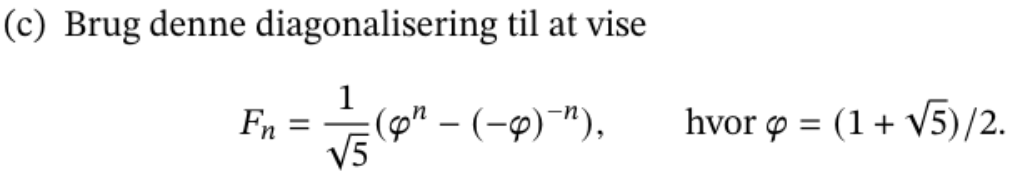

$\color{red} \text{Kør (b) og (c) igennem i hånden, og kopier det herind}$

# 14.4

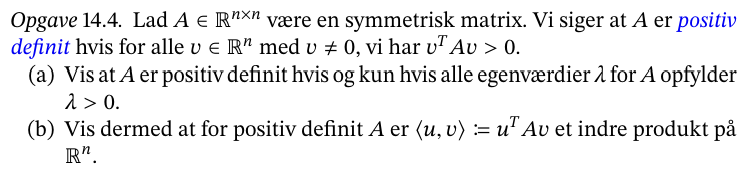

## (a)

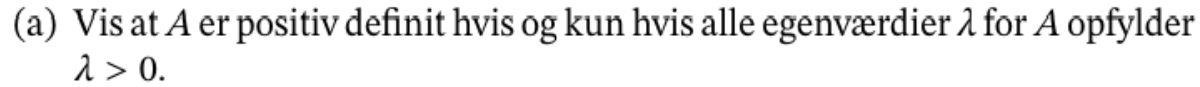

## (b)

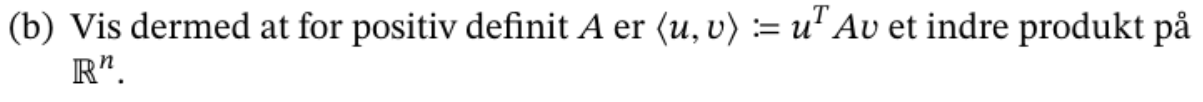